In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Read in csv
df = pd.read_csv("Shopping Mall Customer Segmentation Data .csv")
df

,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
...,...,...,...,...,...
15074,a0504768-a85f-4930-ac24-55bc8e4fec9e,29,Female,97723,30
15075,a08c4e0e-d1fe-48e7-9366-aab11ae409cd,22,Male,73361,74
15076,0e87c25a-268c-401a-8ba1-7111dcde6f1a,18,Female,112337,48
15077,5f388cbe-3373-4e16-b743-38f508f2249f,26,Female,94312,5


In [ ]:
# Show data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer ID     15079 non-null  object
 1   Age             15079 non-null  int64 
 2   Gender          15079 non-null  object
 3   Annual Income   15079 non-null  int64 
 4   Spending Score  15079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 589.2+ KB


In [ ]:
# Describe the distribution of data
df.describe()

,Age,Annual Income,Spending Score
count,15079.000000,15079.000000,15079.000000
mean,54.191591,109742.880562,50.591617
std,21.119207,52249.425866,28.726977
min,18.000000,20022.000000,1.000000
25%,36.000000,64141.000000,26.000000
50%,54.000000,109190.000000,51.000000
75%,72.000000,155008.000000,75.000000
max,90.000000,199974.000000,100.000000


In [ ]:
# Look for null values
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Annual Income,0
Spending Score,0


In [ ]:
# Show value counts for gender to identify all categories and make sure there aren't
# any unnexpected non-null values e.g. "Girl" or "Boy"
df['Gender'].value_counts()

,count
Gender,
Male,7595
Female,7484


In [ ]:
# Drop the CustomerID because it is irrelevant
df.drop(columns=['Customer ID'], inplace=True)

# Encode the Gender column as it is the only object type after dropping customerID
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
# Scale the values, so that they are all in similar ranges
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-1.14551615, -0.99266566,  0.79881267,  1.33705873],
       [ 0.18033514,  1.00738853,  1.44207552,  1.54592857],
       [ 0.36974247,  1.00738853, -0.74320756,  0.88450743],
       ...,
       [-1.71373813,  1.00738853,  0.04965041, -0.09021845],
       [-1.33492347,  1.00738853, -0.2953409 , -1.58711891],
       [-1.6663863 , -0.99266566, -0.60668478, -1.69155383]])

In [ ]:
# Use Principal Component Analysis to reduce the dimensions of the data to two
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(df_scaled)
pca_transformed
pca_df = pd.DataFrame(pca_transformed, columns=['PC1', 'PC2'])
pca_df

,PC1,PC2
0,1.842437,0.907756
1,0.309345,1.362407
2,0.123684,-0.421931
3,1.583000,-1.009438
4,1.685435,0.652765
...,...,...
15074,-0.173914,-1.302897
15075,1.959644,-0.563242
15076,0.510052,-1.101110
15077,-0.682417,-1.725330


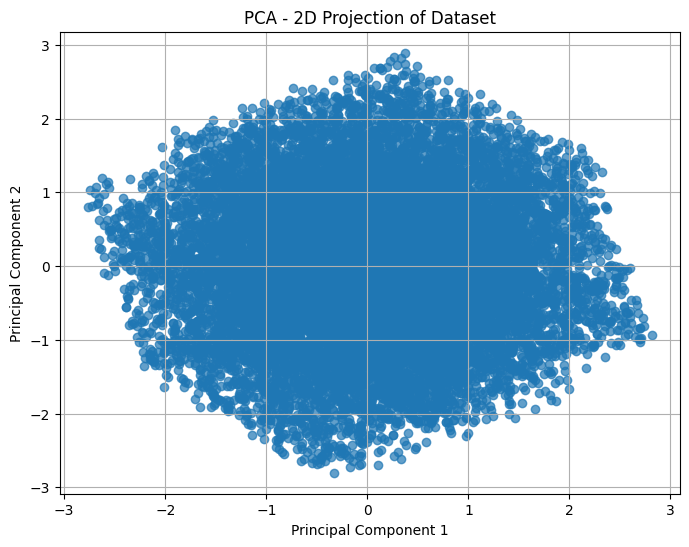

In [ ]:
# Show a scatter graph of the data, to better understand what we are looking at
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Projection of Dataset')
plt.grid(True)
plt.show()

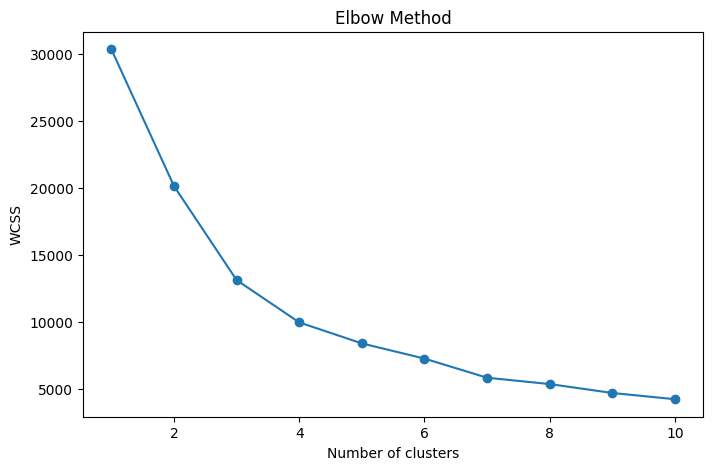

In [ ]:
# Find out the ideal number of clusters using WCSS
wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=1)
    kmeans.fit(pca_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

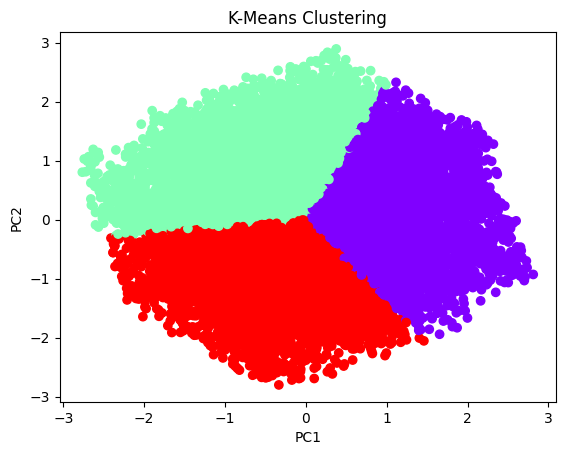

In [ ]:
# 3 seems to be about optimum after the Elbow Graph was produced, so we'll start there
optimal_clusters = 3
pca_df
kmeans = KMeans(n_clusters=optimal_clusters, random_state=1)
kmeans.fit(pca_df)
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans.labels_, cmap='rainbow')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering')
plt.show()

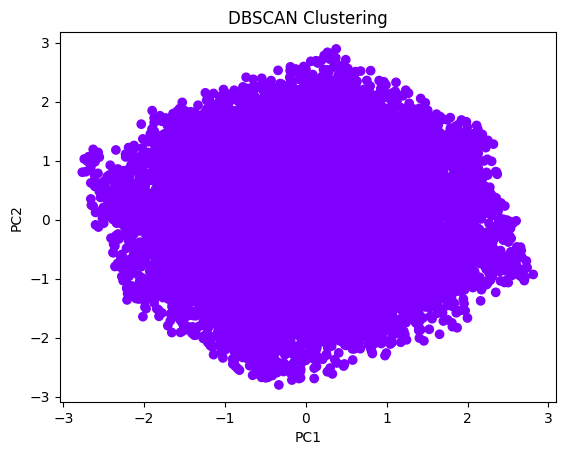

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.7, min_samples=3).fit(pca_df)
db.labels_

plt.scatter(pca_df['PC1'], pca_df['PC2'], c = db.labels_, cmap ='rainbow')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title('DBSCAN Clustering')
plt.show()

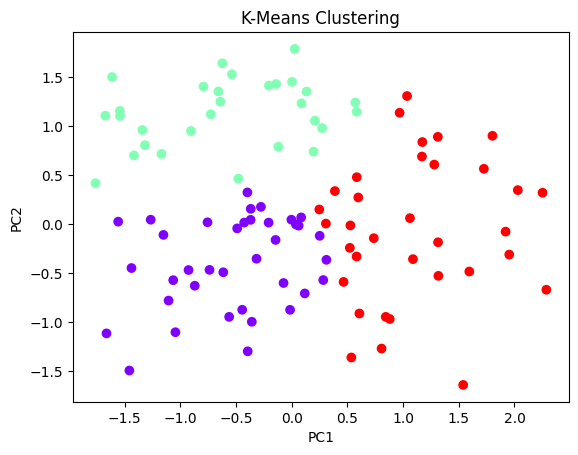

In [ ]:
# Try with a smaller amount of data to see how that affects the clustering
pca_df = pca_df.sample(n=100, random_state=1)
optimal_clusters = 3
pca_df
kmeans = KMeans(n_clusters=optimal_clusters, random_state=1)
kmeans.fit(pca_df)
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans.labels_, cmap='rainbow')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering')
plt.show()

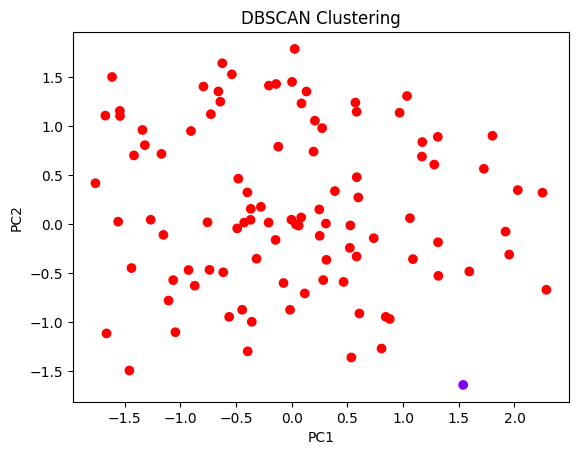

In [ ]:
# Try with a smaller amount of data for DBSCAN
db = DBSCAN(eps=0.7, min_samples=3).fit(pca_df)
db.labels_

plt.scatter(pca_df['PC1'], pca_df['PC2'], c = db.labels_, cmap ='rainbow')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title('DBSCAN Clustering')
plt.show()

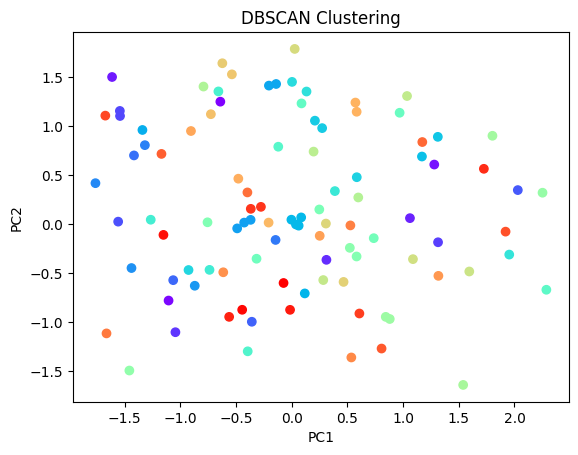

In [ ]:
# Change Epsilon value and min_samples values for DBSCAN
db = DBSCAN(eps=0.1, min_samples=1).fit(pca_df)
db.labels_

plt.scatter(pca_df['PC1'], pca_df['PC2'], c = db.labels_, cmap ='rainbow')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title('DBSCAN Clustering')
plt.show()